<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/perbandingan_Clustering_dan_Klasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Langkah 1: Instalasi & Import Library
!pip install scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

In [17]:
# Langkah 2: Buat Dataset
X_class, y_class = make_classification(n_samples=150, n_features=2, n_classes=3,
n_informative=2, n_redundant=0,
n_clusters_per_class=1, random_state=42)

X_cluster, _ = make_blobs(n_samples=150, centers=3, cluster_std=1.5,
random_state=42)

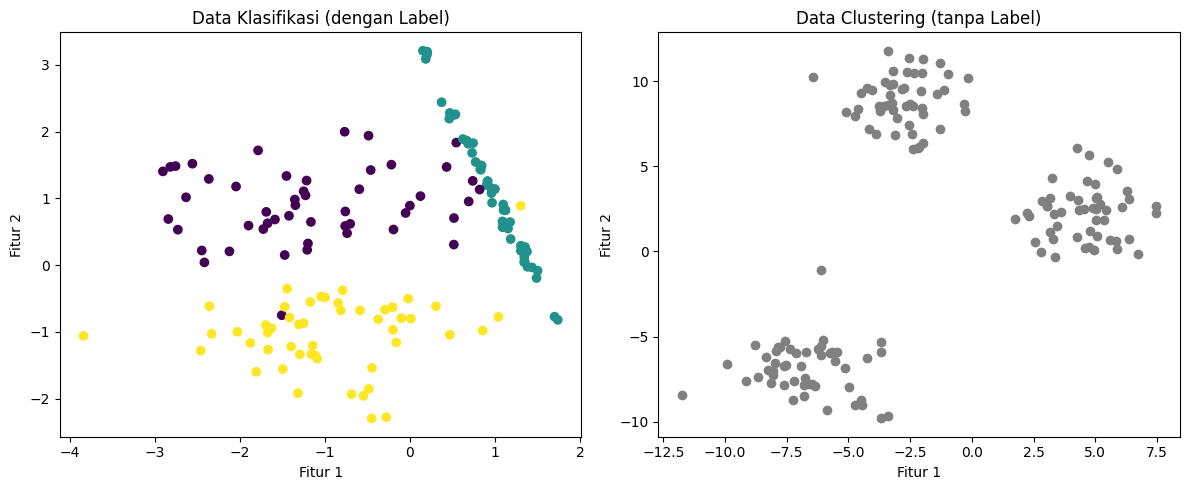

In [18]:
# Langkah 3: Visualisasi Data Mentah
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(X_class[:, 0], X_class[:, 1], c=y_class, cmap='viridis')
axs[0].set_title("Data Klasifikasi (dengan Label)")
axs[0].set_xlabel("Fitur 1")
axs[0].set_ylabel("Fitur 2")

axs[1].scatter(X_cluster[:, 0], X_cluster[:, 1], color='gray')
axs[1].set_title("Data Clustering (tanpa Label)")
axs[1].set_xlabel("Fitur 1")
axs[1].set_ylabel("Fitur 2")

plt.tight_layout()
plt.show()

In [19]:
# Langkah 4: Clustering dengan KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_cluster)

In [20]:
# Langkah 5: Klasifikasi dengan Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2,
random_state=42)
clf = LogisticRegression(multi_class='ovr')
clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

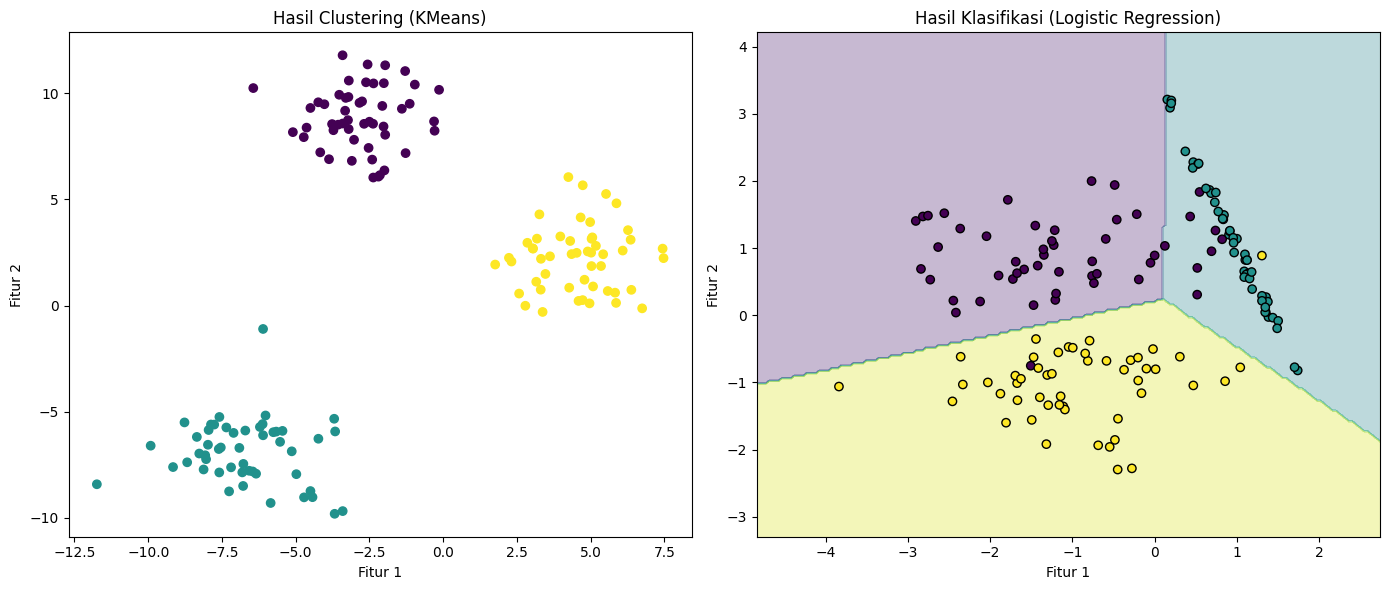

In [21]:
# Langkah 6: Visualisasi Hasil Clustering & Klasifikasi
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Clustering
axs[0].scatter(X_cluster[:, 0], X_cluster[:, 1], c=y_kmeans, cmap='viridis')
axs[0].set_title("Hasil Clustering (KMeans)")
axs[0].set_xlabel("Fitur 1")
axs[0].set_ylabel("Fitur 2")

# Klasifikasi
x_min, x_max = X_class[:, 0].min() - 1, X_class[:, 0].max() + 1
y_min, y_max = X_class[:, 1].min() - 1, X_class[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axs[1].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
axs[1].scatter(X_class[:, 0], X_class[:, 1], c=y_class, cmap='viridis', edgecolor='k')
axs[1].set_title("Hasil Klasifikasi (Logistic Regression)")
axs[1].set_xlabel("Fitur 1")
axs[1].set_ylabel("Fitur 2")

plt.tight_layout()
plt.show()

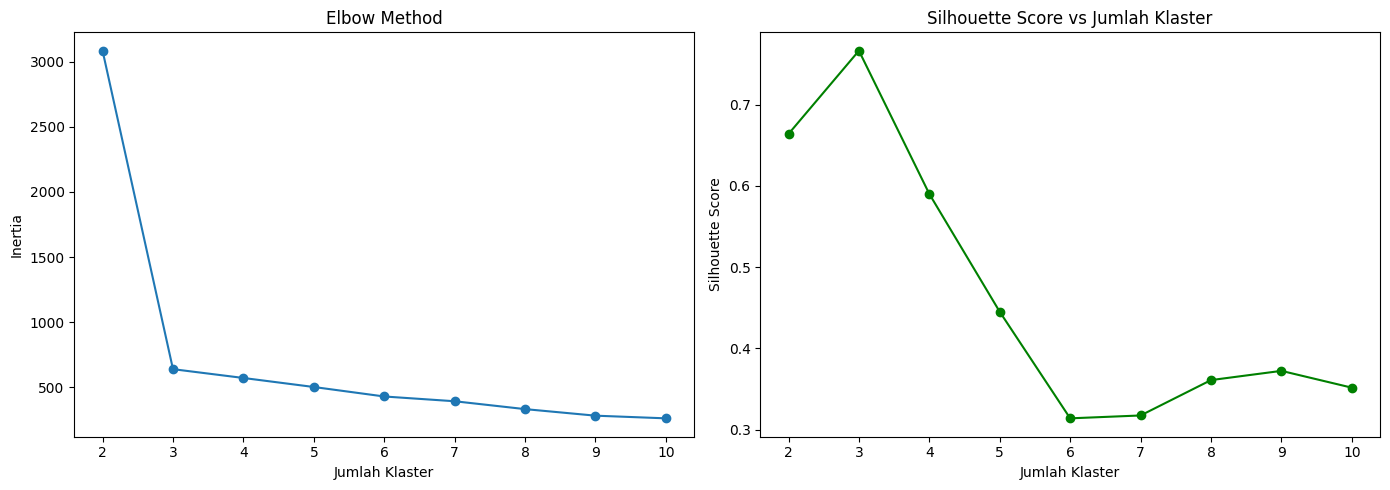

In [22]:
# Langkah 7: Elbow Method & Silhouette Score
inertias = []
silhouette_scores = []
K = range(2, 11)

for k in K:
  kmeans_k = KMeans(n_clusters=k, random_state=42)
  kmeans_k.fit(X_cluster)
  inertias.append(kmeans_k.inertia_)
  silhouette_scores.append(silhouette_score(X_cluster, kmeans_k.labels_))

# Visualisasi

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(K, inertias, marker='o')
axs[0].set_xlabel('Jumlah Klaster')
axs[0].set_ylabel('Inertia')
axs[0].set_title('Elbow Method')

axs[1].plot(K, silhouette_scores, marker='o', color='green')
axs[1].set_xlabel('Jumlah Klaster')
axs[1].set_ylabel('Silhouette Score')
axs[1].set_title('Silhouette Score vs Jumlah Klaster')

plt.tight_layout()
plt.show()